# 5 · Small multiples & multi-variable grids

**Analytical question:** what happens when the same view is repeated across
subsets of the data — or when you want every pairwise view of several variables
at once?

## Charts in this notebook

| Object / function | Level | Dataset | In one line |
|---|---|---|---|
| `FacetGrid` | figure | tips | hand-built grid: `.map()` any plot across rows / columns |
| `PairGrid` | figure | penguins | every variable vs every other, different plot per region |
| `JointGrid` | figure | penguins | a bivariate plot plus its marginal distributions |
| `pairplot` | figure | penguins | the one-call version of `PairGrid` |
| `jointplot` | figure | california_housing | the one-call version of `JointGrid` |

**Method:** the three `*Grid` classes are the manual engines; `pairplot` and
`jointplot` are their one-line shortcuts, shown right after so the trade-off is
visible. Each ends by saving a PNG to `images/`.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from load_data import load_data

sns.set_theme(style="whitegrid")

tips = sns.load_dataset("tips")
penguins = sns.load_dataset("penguins")
housing = load_data("california_housing")

PENGUIN_NUM = ["bill_length_mm", "bill_depth_mm", "flipper_length_mm", "body_mass_g"]

## `FacetGrid`

Figure-level. Build an empty grid keyed by `row` / `col`, then `.map()` (or
`.map_dataframe()`) a plotting function onto every panel. The engine behind
`relplot` / `displot` / `catplot`.

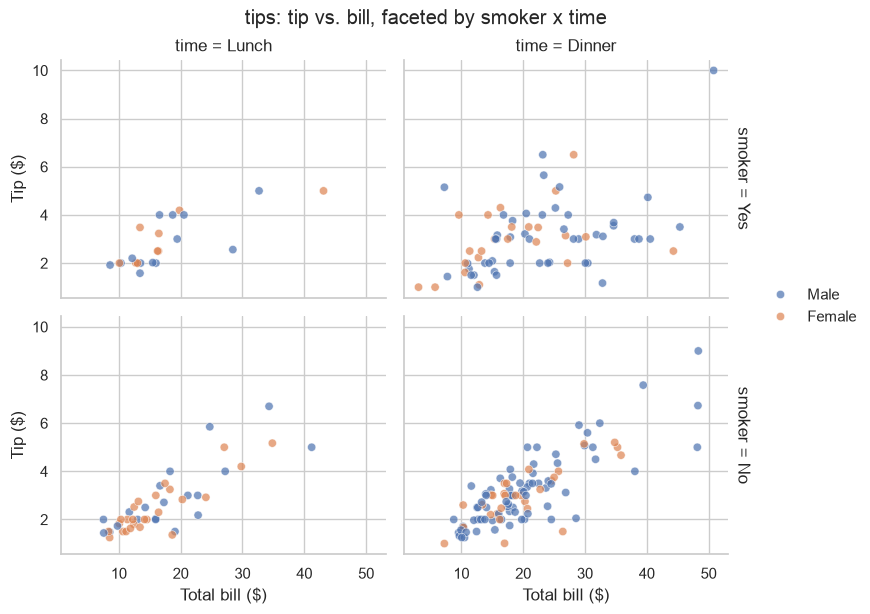

In [2]:
g = sns.FacetGrid(
    tips, row="smoker", col="time",
    margin_titles=True, height=3, aspect=1.3,
)
g.map_dataframe(sns.scatterplot, x="total_bill", y="tip", hue="sex", alpha=0.7)
g.add_legend()
g.set_axis_labels("Total bill ($)", "Tip ($)")
g.figure.suptitle("tips: tip vs. bill, faceted by smoker x time", y=1.02)
g.savefig("images/5_facetgrid.png", dpi=150, bbox_inches="tight")

**Best for**

- Small multiples of a plot the figure-level wrappers don't offer, or when you want to layer several `.map()` calls on the same grid.
- `margin_titles=True`, `col_wrap=`, `sharex` / `sharey`, `despine=` for the usual adjustments.
- **Not** needed when `relplot` / `displot` / `catplot` already draw what you want — those *are* a `FacetGrid` with a friendlier signature and a managed legend.

[`FacetGrid` docs](https://seaborn.pydata.org/generated/seaborn.FacetGrid.html)

## `PairGrid`

Figure-level. A square grid of every variable against every other, with the
upper triangle, lower triangle and diagonal each controlled separately.

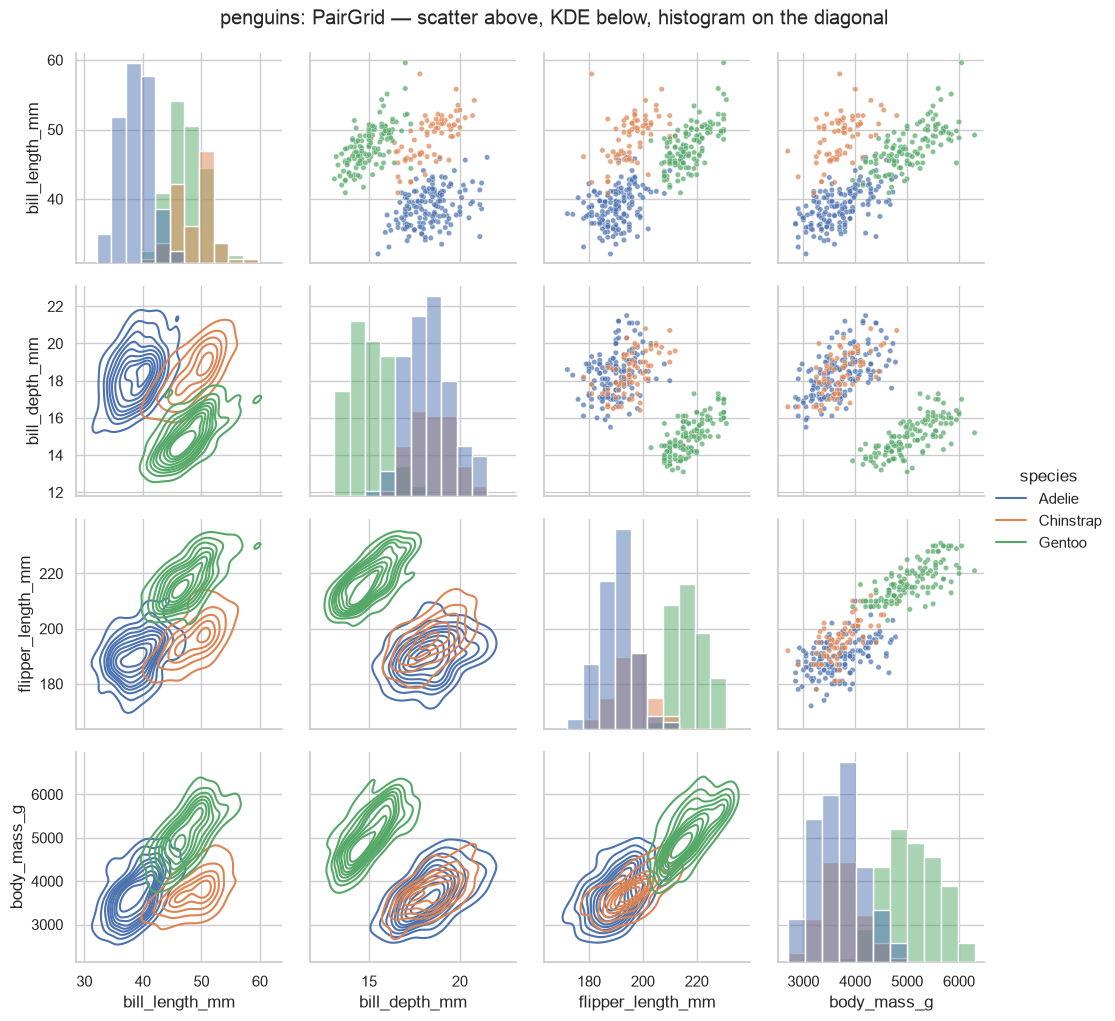

In [3]:
g = sns.PairGrid(penguins, vars=PENGUIN_NUM, hue="species", diag_sharey=False)
g.map_upper(sns.scatterplot, s=15, alpha=0.7)
g.map_lower(sns.kdeplot)
g.map_diag(sns.histplot)
g.add_legend()
g.figure.suptitle("penguins: PairGrid — scatter above, KDE below, histogram on the diagonal", y=1.02)
g.savefig("images/5_pairgrid.png", dpi=150, bbox_inches="tight")

**Best for**

- Choosing a *different* plot per region: raw scatter above the diagonal, smoothed density below, a 1-D distribution on it (`map_upper` / `map_lower` / `map_diag`).
- Any per-cell plot `pairplot` doesn't expose.
- **Not** the quick route (that's `pairplot`), and it turns into a wall of tiny panels past ~6–8 variables.

[`PairGrid` docs](https://seaborn.pydata.org/generated/seaborn.PairGrid.html)

## `JointGrid`

Figure-level. One central bivariate plot with a marginal distribution on each
axis — the joint layer and the marginal layers set independently.

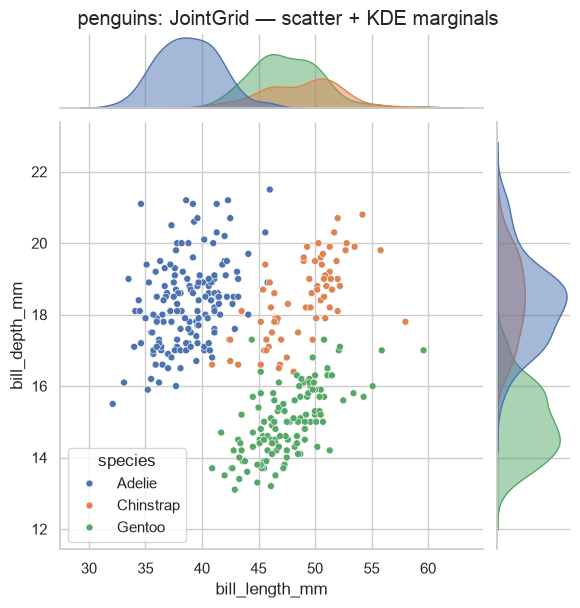

In [4]:
g = sns.JointGrid(data=penguins, x="bill_length_mm", y="bill_depth_mm", hue="species", height=6)
g.plot_joint(sns.scatterplot, s=25)
g.plot_marginals(sns.kdeplot, fill=True, alpha=0.5)
g.figure.suptitle("penguins: JointGrid — scatter + KDE marginals", y=1.01)
g.savefig("images/5_jointgrid.png", dpi=150, bbox_inches="tight")

**Best for**

- A scatter (or any bivariate plot) where you also want to see each variable's own distribution, and the joint / marginal layers need different functions or extra layers (a regression plus a rug, say).
- `plot_joint` and `plot_marginals` take any seaborn or matplotlib function.
- **Not** worth the extra lines for a standard scatter-plus-histogram — `jointplot` does that in one call.

[`JointGrid` docs](https://seaborn.pydata.org/generated/seaborn.JointGrid.html)

## `pairplot`

Figure-level. The one-call `PairGrid`: a scatter matrix with a distribution on
the diagonal. `corner=True` drops the redundant upper half.

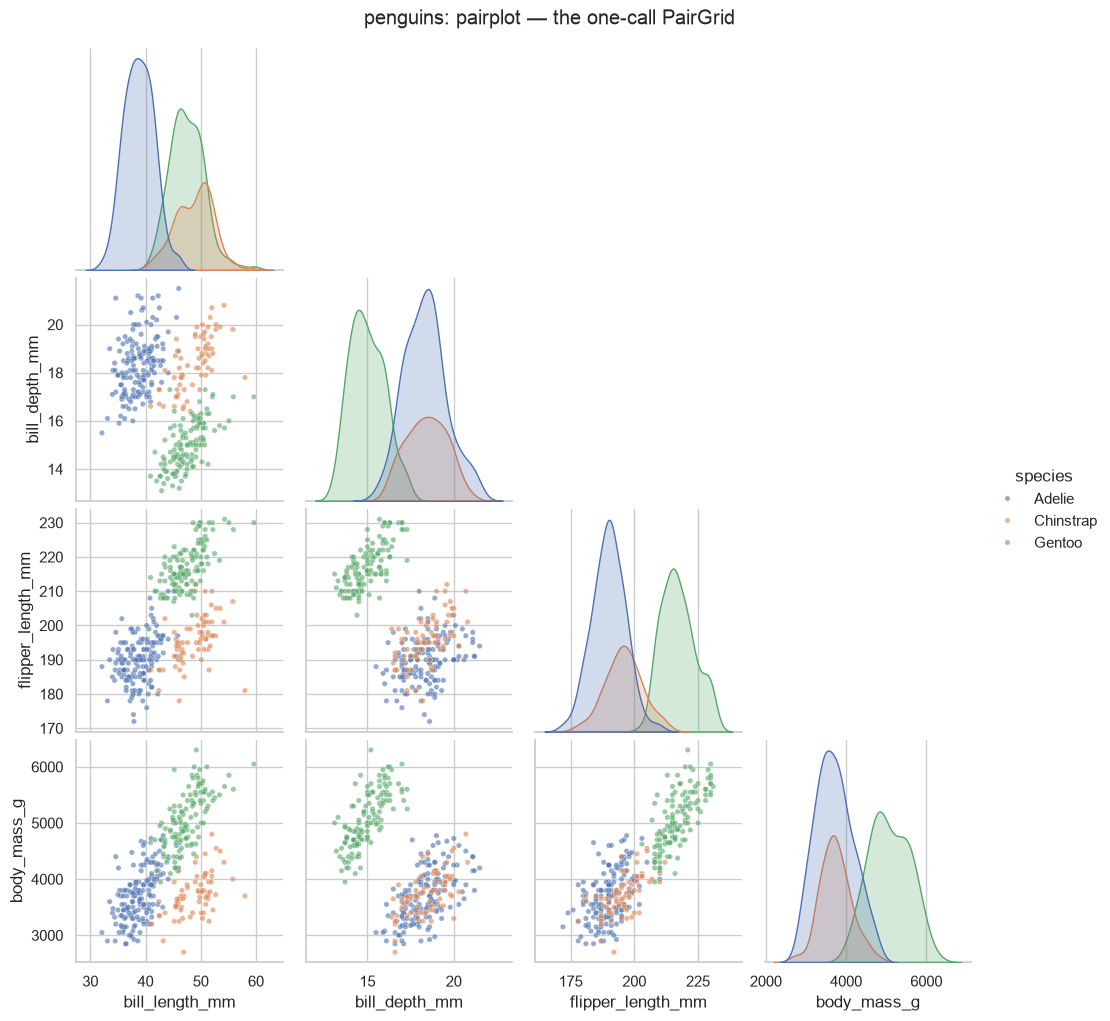

In [5]:
g = sns.pairplot(
    penguins, vars=PENGUIN_NUM, hue="species",
    diag_kind="kde", corner=True,
    plot_kws={"s": 15, "alpha": 0.6},
)
g.figure.suptitle("penguins: pairplot — the one-call PairGrid", y=1.02)
g.savefig("images/5_pairplot.png", dpi=150, bbox_inches="tight")

**Best for**

- The fastest way to eyeball every pairwise relationship and every one-variable distribution at once, split by `hue`.
- `diag_kind="hist" | "kde"`, `kind="scatter" | "reg"`, `corner=True`.
- **Not** customisable past its keywords — move to `PairGrid` when you hit that wall — and impractical for many variables.

[`pairplot` docs](https://seaborn.pydata.org/generated/seaborn.pairplot.html)

## `jointplot`

Figure-level. The one-call `JointGrid`: `kind=` sets the central plot, the
marginals follow automatically.

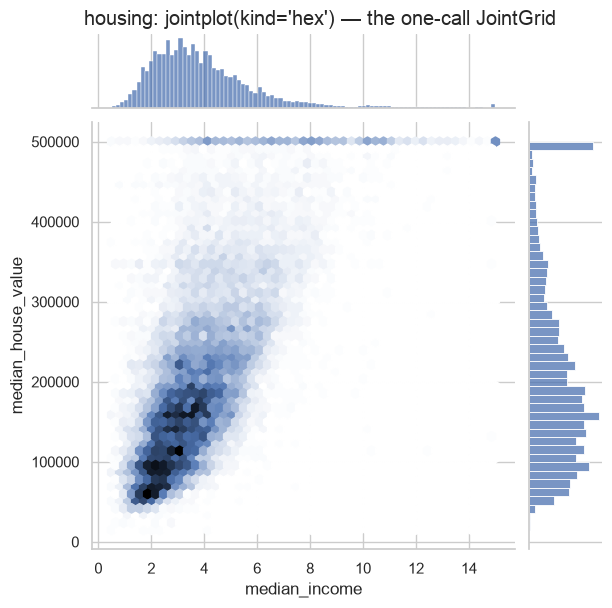

In [6]:
g = sns.jointplot(
    data=housing, x="median_income", y="median_house_value",
    kind="hex", height=6,
)
g.figure.suptitle("housing: jointplot(kind='hex') — the one-call JointGrid", y=1.01)
g.savefig("images/5_jointplot.png", dpi=150, bbox_inches="tight")

**Best for**

- A quick bivariate view with marginals: `kind="scatter" | "kde" | "hist" | "hex" | "reg"`.
- `kind="hex"` (here) is the one to use at large N — it bins the points into a density instead of an unreadable blob, and the $500k value cap shows up as a bright horizontal band.
- **Not** for more than one grouping, or bespoke joint / marginal layers — that's `JointGrid`.

[`jointplot` docs](https://seaborn.pydata.org/generated/seaborn.jointplot.html)